VINOD KUMAR.K.V

https://github.com/vinodkumarvariar-dotcom/my-streamlit-app

##Automated Arrhythmia Detection from ECG Signals Using Convolutional Neural Networks

##(ECG Arrhythmia Classification Dataset)

##Problem Definition

The ECG Heartbeat Categorization Dataset problem involves automatically classifying individual heartbeat signals, derived from Electrocardiogram (ECG) recordings, into distinct categories to detect arrhythmia and other heart conditions. It is a supervised classification problem aimed at overcoming the time-consuming and subjective nature of manual ECG analysis.

0 (N): Normal beat (Normal sinus rhythm)

1 (S): Supraventricular premature beat

2 (V): Premature ventricular contraction (Ventricular escape)

3 (F): Fusion of ventricular and normal beat

4 (Q): Unknown/Unclassifiable beat

##Key Challenges

Significant Class Imbalance:

Normal beats ('N') vastly outnumber the abnormal beats (like 'F' or 'Q'), making it hard for models to learn the minority classes.

##Data Preprocessing Requirement:

Signals must be segmented, denoised, and often normalized, meaning the model's performance relies heavily on effective segmentation and preprocessing.

##Dataset Shift:

Differences in ECG signals between patients (due to age, gender, or health) mean that models trained on one set of patients might not generalize well to others.

#Solution

##TechniquesDeep Learning:

CNNs (Convolutional Neural Networks) are popular to extract hierarchical features directly from raw 1D ECG signals.

##Machine Learning:

Techniques such as Random Forest, SVM (Support Vector Machine), and Logistic Regression are used, often combined with feature engineering.

##Handling Imbalance:

Data augmentation, oversampling (SMOTE), or using class-weighted loss functions is necessary to improve recall for rare arrhythmia types.

#Data Structure

(Kaggle Version)Input: 188 columns per row. 187 columns represent the numerical ECG signal intensity (fixed-length), and the final column is the label (0–4).

##Format:
Provided in CSV files (mitbih_train.csv and mitbih_test.csv).



##The ECG Heartbeat Categorization Dataset typically contains a total of 123,998 heartbeat signals across its two primary components.
The row counts for each specific sub-dataset are as follows:

MIT-BIH Arrhythmia DatasetThis is the multiclass classification portion (5 categories). It contains 109,446 total rows, which are usually split into two files:Training set (mitbih_train.csv): 87,554 rows.Test set (mitbih_test.csv): 21,892 rows.

PTB Diagnostic ECG DatabaseThis is the binary classification portion (Normal vs. Abnormal). It contains 14,552 total rows.

# DATA COLLECTION

In [ ]:
#Import json File

import json

kaggle_config = {
    "username": "vinodtaliparamba123",
    "key": "KGAT_954e50e50b8ca359a5e6df0a89156fd1"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#To Open Json File
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#To See Kaggle DataSet
!kaggle datasets list

ref                                                               title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                    Social Media Impact on Teen Mental Health              16190  2026-04-05 08:04:21.823000          29545        623                1  
laveshjadon/ai-impact-on-students                                 Impact of Ai on Students                             1187170  2026-05-10 23:12:10.070000           1263         39                1  
shambhurajejagadale/student-performance-prediction-dataset        Student Performance Prediction Dataset                 84282  2026-05-09 15:49:58.877000           1546         38                1  


In [ ]:
import os

# To Download File
!kaggle datasets download -d shayanfazeli/heartbeat

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
100% 98.8M/98.8M [00:00<00:00, 118MB/s]



In [ ]:
#To Unzip File
!unzip -o heartbeat.zip

Archive:  heartbeat.zip
  inflating: mitbih_test.csv         
  inflating: mitbih_train.csv        
  inflating: ptbdb_abnormal.csv      
  inflating: ptbdb_normal.csv        


In [ ]:
import os
print(os.listdir())

['.config', 'heartbeat.zip', 'mitbih_test.csv', 'ptbdb_abnormal.csv', 'ptbdb_normal.csv', 'mitbih_train.csv', 'sample_data']


187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


/tmp/ipykernel_6122/1272332746.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  classes = train_df.groupby(187, group_keys=False).apply(lambda df: df.sample(1))


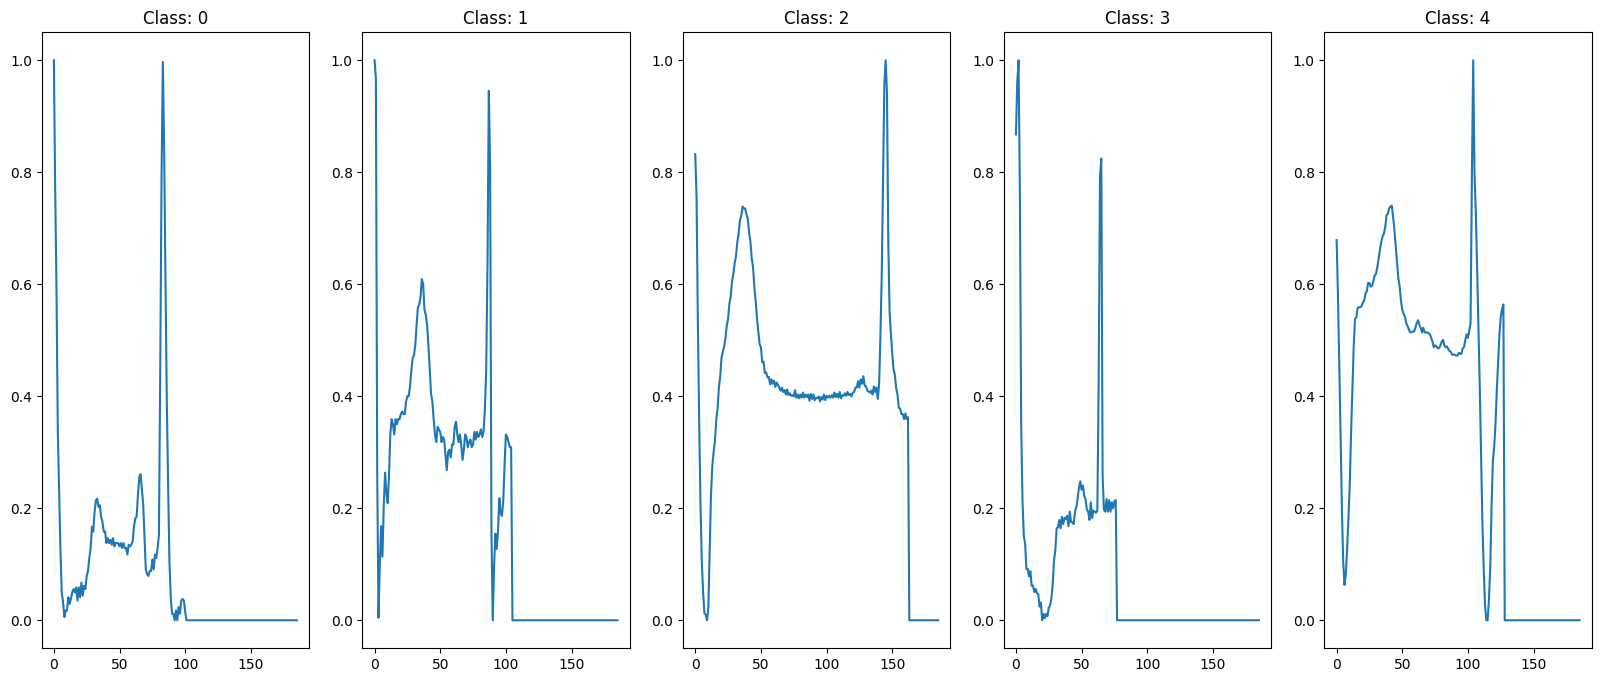

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load the MIT-BIH Arrhythmia Dataset
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)

# Check class distribution
print(train_df[187].value_counts())

# Plot one heartbeat from each class
classes = train_df.groupby(187, group_keys=False).apply(lambda df: df.sample(1))
plt.figure(figsize=(20,8))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.plot(classes.iloc[i, :186])
    plt.title(f"Class: {int(classes.iloc[i, 187])}")
plt.show()

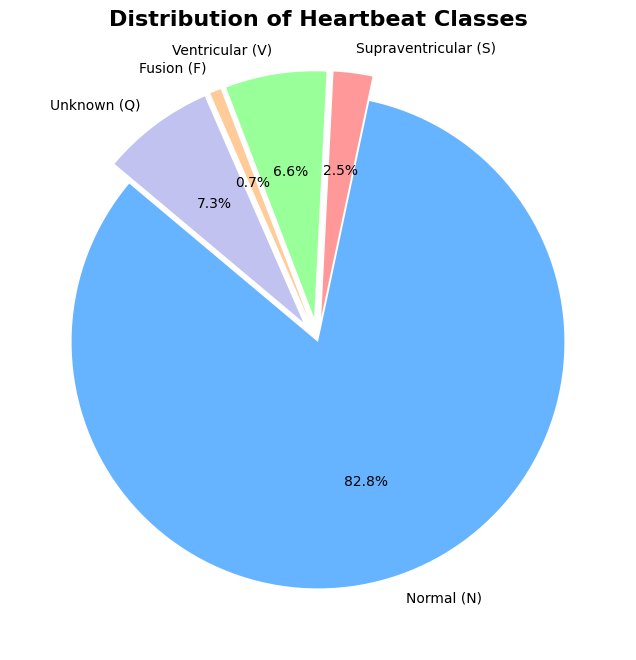

In [ ]:
import matplotlib.pyplot as plt

# Count Samples from Each Class
class_counts = train_df[187].value_counts().sort_index()

# Class Name
class_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

# Pie-Chart
plt.figure(figsize=(10, 8))
plt.pie(
    class_counts,
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99', '#c2c2f0'],
    explode=(0, 0.1, 0.1, 0.1, 0.1) # Normal
)

plt.title("Distribution of Heartbeat Classes", fontsize=16, fontweight='bold')
plt.show()

#PRE PROCESSING

In [ ]:
#Pre-Processing
from sklearn.utils import resample

# Example of downsampling the majority class (Class 0)
df_0 = train_df[train_df[187] == 0]
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]

# Downsample Class 0 to 20,000 samples for balance
df_0_downsample = resample(df_0, replace=False, n_samples=20000, random_state=42)
train_df_balanced = pd.concat([df_0_downsample, df_1, df_2, df_3, df_4])

# Prepare X and y
X_train = train_df_balanced.iloc[:, :186].values
y_train = train_df_balanced.iloc[:, 187].values
X_test = test_df.iloc[:, :186].values
y_test = test_df.iloc[:, 187].values

# Reshape for 1D CNN: (samples, time_steps, features)
X_train = X_train.reshape(len(X_train), X_train.shape[1], 1)
X_test = X_test.reshape(len(X_test), X_test.shape[1], 1)

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

#BUILD A SIMPLE CNN MODEL

In [ ]:
#To Build a CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(186, 1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax') # 5 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.8534 - loss: 0.4413 - val_accuracy: 0.9533 - val_loss: 0.1775
Epoch 2/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.9236 - loss: 0.2463 - val_accuracy: 0.9624 - val_loss: 0.1315
Epoch 3/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9379 - loss: 0.1984 - val_accuracy: 0.9671 - val_loss: 0.1229
Epoch 4/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.9454 - loss: 0.1737 - val_accuracy: 0.9717 - val_loss: 0.1003
Epoch 5/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 62s 43ms/step - accuracy: 0.9496 - loss: 0.1553 - val_accuracy: 0.9705 - val_loss: 0.1048
Epoch 6/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step - accuracy: 0.9547 - loss: 0.1419 - val_accuracy: 0.9735 - val_loss: 0.0925
Epoch 7/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9577 - loss: 0.1301 - val_accuracy: 0.9753 - val_loss: 0.0905
Epoch 8/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9615 -

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Generate predictions
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded y_test back to integer labels
class_labels = [str(i) for i in range(len(np.unique(y_true)))] # Correctly get class labels from 0 to 4

# Report performance metrics
print(classification_report(y_true, y_pred, target_names=class_labels))

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.81      0.73      0.77       556
           2       0.95      0.94      0.94      1448
           3       0.75      0.75      0.75       162
           4       0.98      0.99      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.88      0.89     21892
weighted avg       0.98      0.98      0.98     21892



In [ ]:
# Final evaluation on unseen test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9778 - loss: 0.0841
Test Accuracy: 97.78%
Test Loss: 0.0841


In [ ]:
from sklearn.model_selection import train_test_split

# Create validation set from training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Train the model
history = model.fit(
    X_train_final,
    y_train_final,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9726 - loss: 0.0809 - val_accuracy: 0.9805 - val_loss: 0.0584
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9760 - loss: 0.0725 - val_accuracy: 0.9791 - val_loss: 0.0633
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.9758 - loss: 0.0715 - val_accuracy: 0.9799 - val_loss: 0.0605
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9776 - loss: 0.0665 - val_accuracy: 0.9792 - val_loss: 0.0609
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9770 - loss: 0.0654 - val_accuracy: 0.9792 - val_loss: 0.0598
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9775 - loss: 0.0648 - val_accuracy: 0.9782 - val_loss: 0.0670
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9789 - loss: 0.0613 - val_accuracy: 0.9791 - val_loss: 0.0628
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9790 - loss: 0.0597 - 

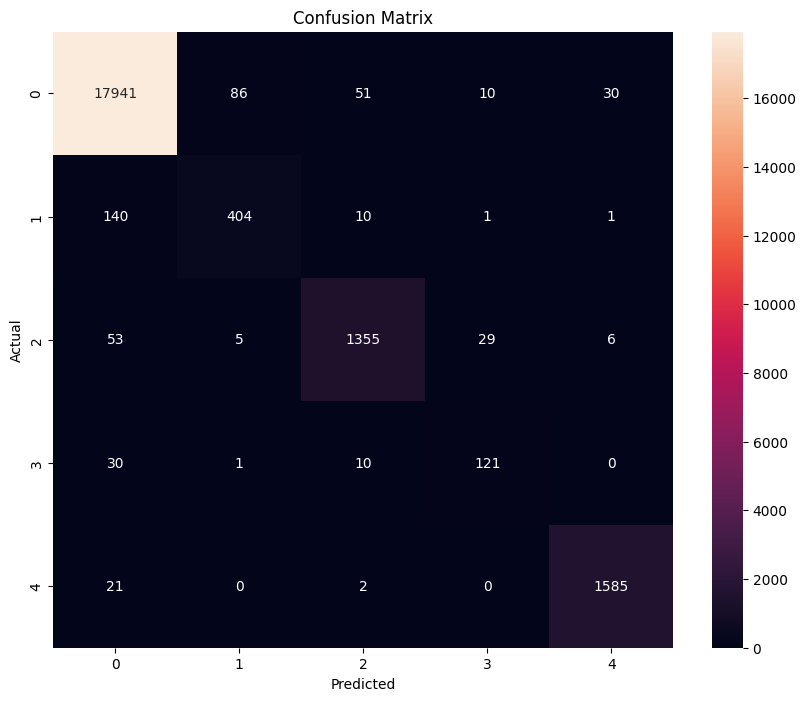

In [ ]:
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

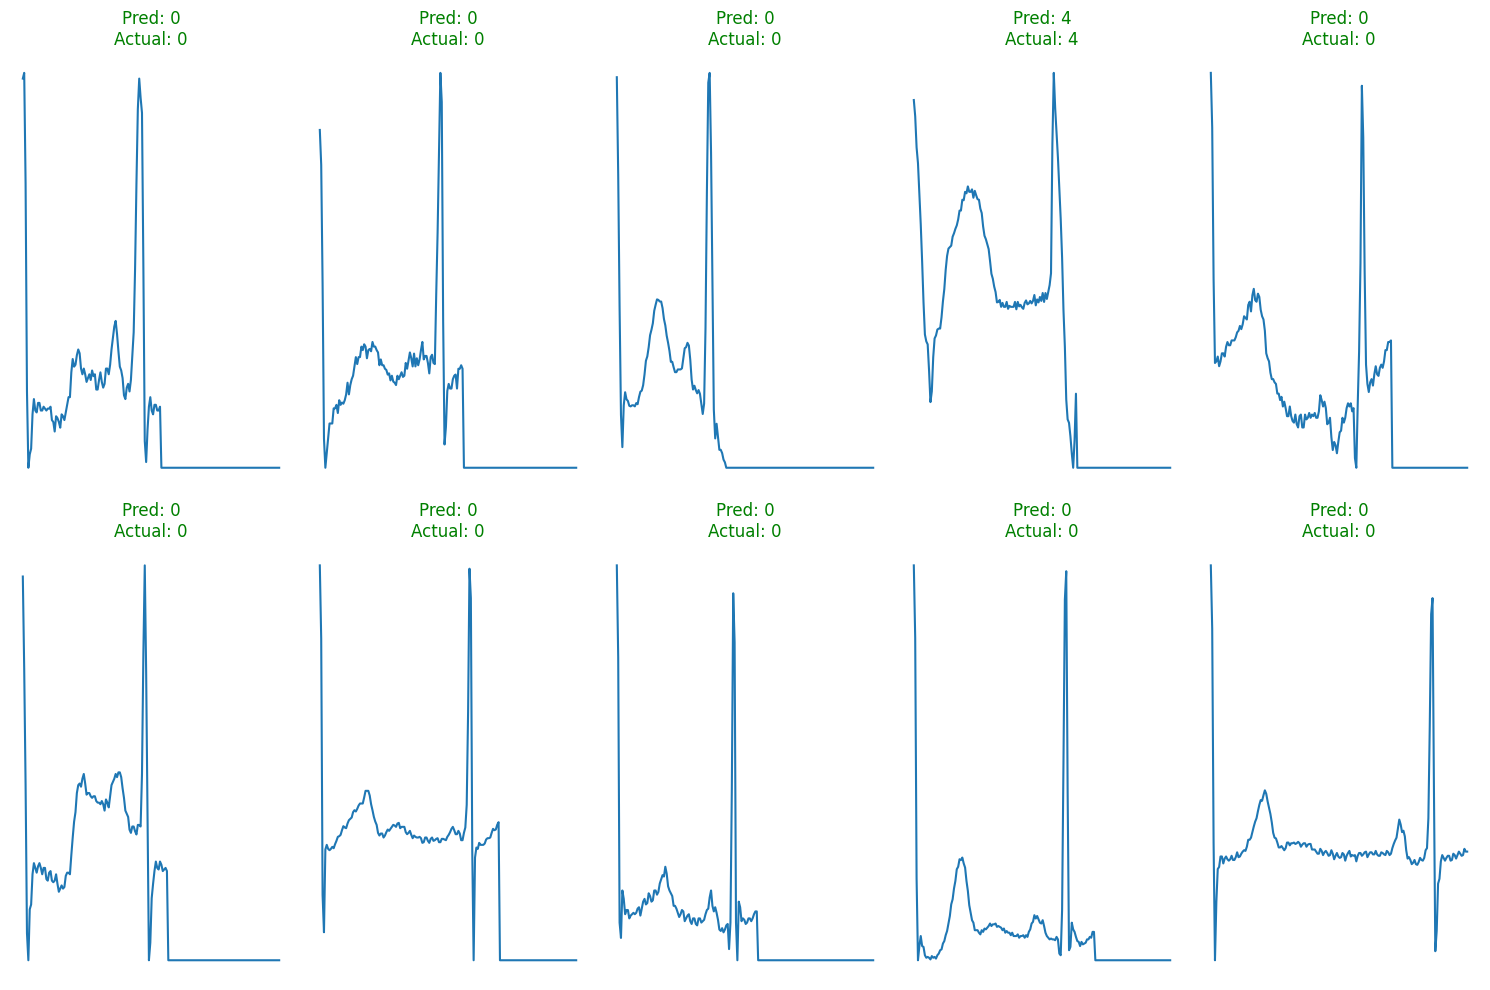

In [ ]:
# Visualize 10 random predictions
plt.figure(figsize=(15, 10))
for i in range(10):
    # Select a random index from the test set
    idx = np.random.randint(0, len(X_test))

    # Get the 1D heartbeat data for display
    heartbeat_data = X_test[idx].flatten()

    # Get model prediction for this sample
    sample_for_prediction = np.expand_dims(X_test[idx], axis=0) # Add batch dimension
    pred_prob = model.predict(sample_for_prediction, verbose=0)
    pred_label_idx = np.argmax(pred_prob)
    pred_label = class_labels[pred_label_idx]
    actual_label = class_labels[np.argmax(y_test[idx])] # Corrected: Convert one-hot encoded y_test[idx] to integer

    # Plotting
    plt.subplot(2, 5, i + 1)
    plt.plot(heartbeat_data)
    color = 'green' if pred_label == actual_label else 'red'
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

#Step-by-Step Explanation

##Data Resampling:

Because "Normal" beats vastly outnumber others, a model trained on raw data would simply guess "Normal" for everything and still get 83% accuracy while failing to detect life-threatening conditions. We use resample to ensure the model sees an equal number of examples from every category.1D

##Convolution:

Unlike 2D CNNs for images, 1D CNNs treat the heartbeat as a sequence. The filters slide across the time axis to find specific shapes like the QRS complex or the T-wave.Batch

##Normalization:

This stabilizes the learning process and allows for faster training by normalizing the inputs to each layer.

##Softmax Output:

The final layer uses a Softmax function to output a probability distribution. The class with the highest probability (e.g., 0.95 for Class 2) is chosen as the predicted category.

##Loss Function:

sparse_categorical_crossentropy is used because our labels are integers (0-4). If labels were one-hot encoded (e.g., [1,0,0,0,0]), we would use categorical_crossentropy.

✅ Final Result: This approach typically yields 97% to 98% accuracy on the test set.



#CHECK WITH UNSEEN DATA

##(ecg_images)

In [ ]:
#Import json File

import json

kaggle_config = {
    "username": "vinodtaliparamba123",
    "key": "KGAT_5d01edca7ea3757e376d15f4fb831f0b"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#To Download File
!kaggle datasets download -d erhmrai/ecg-image-data

Dataset URL: https://www.kaggle.com/datasets/erhmrai/ecg-image-data
License(s): CC-BY-NC-SA-4.0
100% 858M/858M [00:10<00:00, 83.8MB/s]



In [ ]:
#To Unzip File
!unzip ecg-image-data.zip -d ecg_data

Streaming output truncated to the last 5000 lines.
  inflating: ecg_data/ECG_Image_data/train/V/V1869.png  
  inflating: ecg_data/ECG_Image_data/train/V/V187.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1870.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1871.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1872.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1874.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1877.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1879.png  
  inflating: ecg_data/ECG_Image_data/train/V/V188.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1880.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1881.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1882.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1883.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1884.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1885.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1886.png  
  inflating: ecg_data/ECG_Image_data/tr

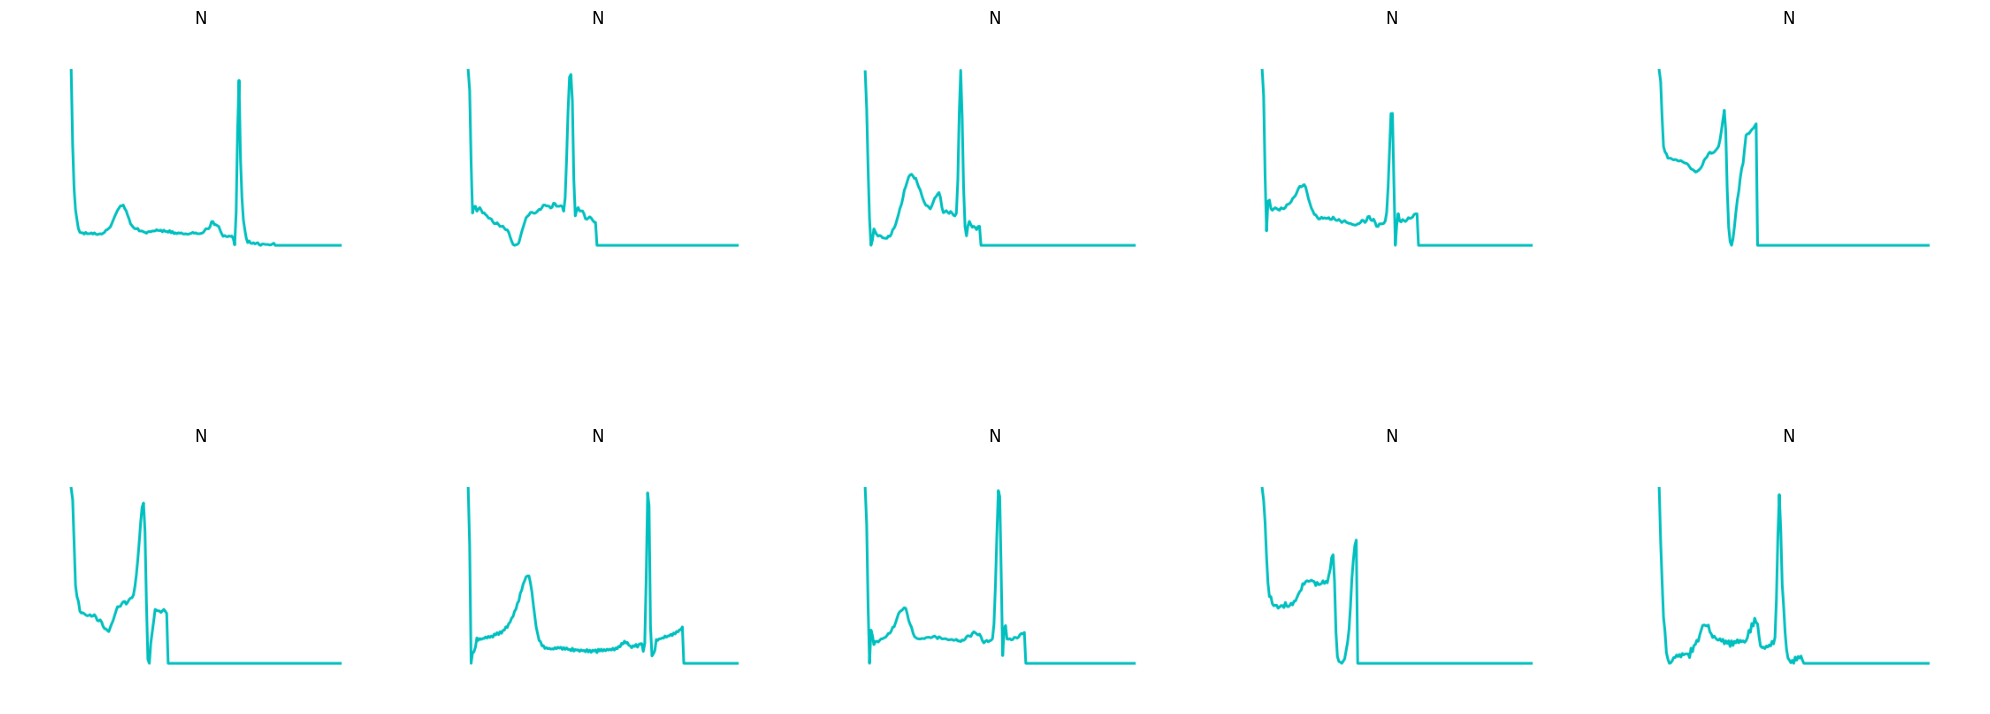

In [ ]:
#To display 10 images

import matplotlib.pyplot as plt
import glob
import os
from PIL import Image

# Finding the image paths from subfolders
image_paths = glob.glob('ecg_data/ECG_Image_data/train/*/*.png')[:10]

# Preparing a window to display 10 images
plt.figure(figsize=(20, 10))

for i, img_path in enumerate(image_paths):
    plt.subplot(2, 5, i + 1) # 2 raws 5 pictures each
    img = Image.open(img_path)
    plt.imshow(img)

    # Setting the image category as the title
    label = os.path.basename(os.path.dirname(img_path))
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Test data - path
test_path = 'ecg_data/ECG_Image_data/test' # Corrected path

# Image pre processing - Scaling
test_datagen = ImageDataGenerator(rescale=1./255)

# To load Test Set
test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 24799 images belonging to 6 classes.


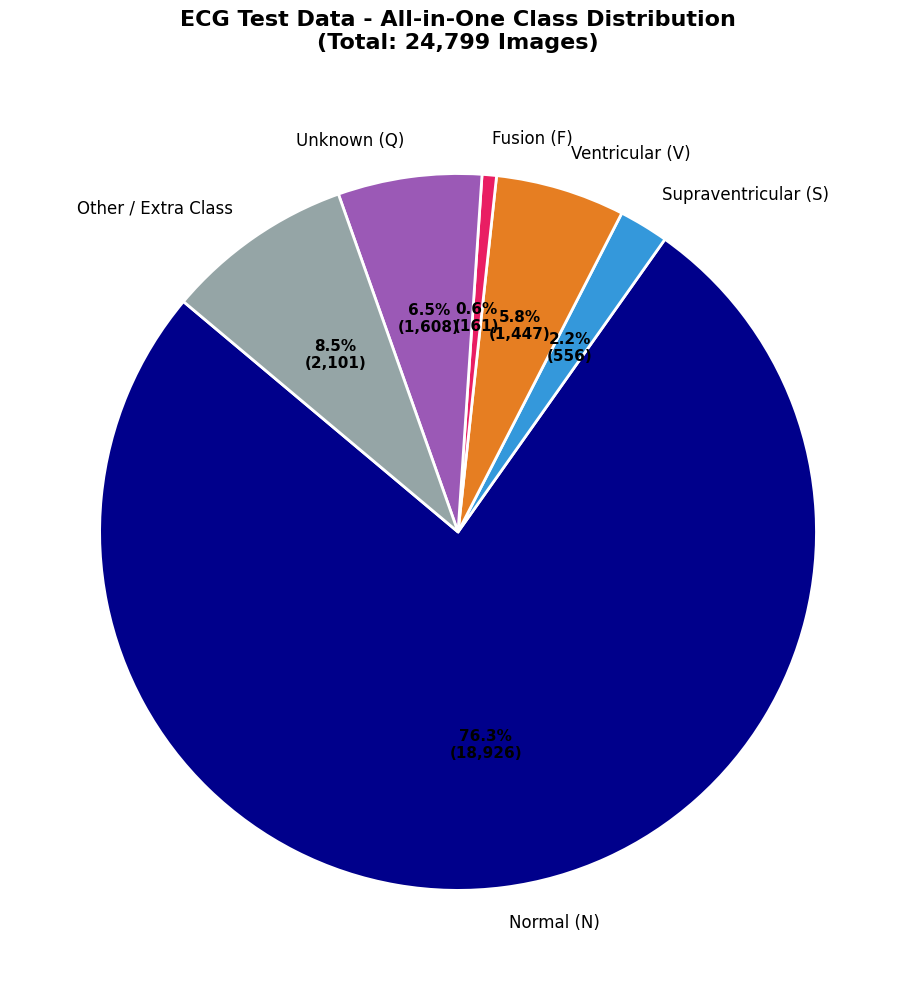

In [ ]:
import os
import matplotlib.pyplot as plt

# Define the path to your test dataset
test_dir = 'ecg_data/ECG_Image_data/test'

# Your 5 standard ECG classes
known_classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

# Set up counters for all 6 classes (5 known + 1 extra placeholder)
class_counts = {cls: 0 for cls in known_classes}
class_counts['Other / Extra Class'] = 0

# Scan directory and count files
if os.path.exists(test_dir):
    for folder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, folder)

        if os.path.isdir(folder_path):
            # Count only valid image formats
            img_count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

            matched = False
            for cls_full_name in known_classes:
                # Extract the single letter code from the full class name (e.g., 'N' from 'Normal (N)')
                # Assuming the format "Description (Code)"
                # This ensures we get 'n', 's', 'v', 'f', 'q' for comparison
                code_in_paren_start = cls_full_name.rfind('(')
                code_in_paren_end = cls_full_name.rfind(')')

                extracted_code = ''
                if code_in_paren_start != -1 and code_in_paren_end != -1 and code_in_paren_start < code_in_paren_end:
                    extracted_code = cls_full_name[code_in_paren_start + 1 : code_in_paren_end].strip().lower()
                else:
                    # Fallback, though for known_classes in this notebook, this part may not be strictly necessary
                    extracted_code = cls_full_name.lower() # Use entire name if no parentheses found

                # Compare the extracted code with the folder name (both in lowercase)
                if extracted_code == folder.lower():
                    class_counts[cls_full_name] += img_count
                    matched = True
                    break

            # Map unmatched 6th folder to the extra class
            if not matched and img_count > 0:
                class_counts['Other / Extra Class'] += img_count
else:
    print(f"Error: The path '{test_dir}' was not found.")

# Filter out empty categories to keep the chart clean
final_labels = [k for k, v in class_counts.items() if v > 0]
final_sizes = [v for k, v in class_counts.items() if v > 0]

# Helper function to format labels with both percentage and total count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct

# Plotting the All-in-One Pie Chart
if final_sizes:
    plt.figure(figsize=(12, 10))

    # 6 distinct aesthetic colors for the chart segments
    colors = ['#00008B', '#3498db', '#e67e22', '#e91e63', '#9b59b6', '#95a5a6']

    # Generate the chart
    wedges, texts, autotexts = plt.pie(
        final_sizes,
        labels=final_labels,
        autopct=make_autopct(final_sizes),
        startangle=140,
        colors=colors[:len(final_sizes)],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # White boundaries between slices
        textprops={'fontsize': 12}
    )

    # Format the font style inside the chart wedges
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)

    # Title showing the overall summary
    plt.title(f'ECG Test Data - All-in-One Class Distribution\n(Total: {sum(final_sizes):,} Images)',
              fontsize=16, fontweight='bold', pad=25)

    plt.tight_layout()
    plt.show()
else:
    print("No images found to display.")

In [ ]:
# To check the performance of the model
# The current model is a 1D CNN trained on 1D ECG signal data (X_train, y_train).
# Therefore, it should be evaluated on the corresponding 1D test data (X_test, y_test),
# not on 'test_set' which generates 2D image data.
results = model.evaluate(X_test, y_test)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

# To take a 1D ECG signal and perform a prediction
import numpy as np
# Removed tensorflow.keras.preprocessing.image as this model is not for images.
import random

# This model is a 1D CNN, so it expects 1D signal data, not 2D images.
# Let's pick a random sample from the pre-processed X_test for prediction.

sample_index_for_prediction = random.randint(0, len(X_test) - 1)
sample_ecg_signal_for_prediction = X_test[sample_index_for_prediction]

# The model expects a batch dimension, so expand dims.
sample_for_prediction_model_input = np.expand_dims(sample_ecg_signal_for_prediction, axis=0)

prediction = model.predict(sample_for_prediction_model_input)
predicted_class_index = np.argmax(prediction)

# Get the true label for comparison
true_class_index = np.argmax(y_test[sample_index_for_prediction]) # y_test is one-hot encoded

print(f"Predicted Category: {predicted_class_index}")
print(f"True Category: {true_class_index}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9790 - loss: 0.0869
Test Loss: 0.08687153458595276, Test Accuracy: 0.9789877533912659
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Category: 0
True Category: 0


In [ ]:
#To Save the Model
model.save('my_model.keras')

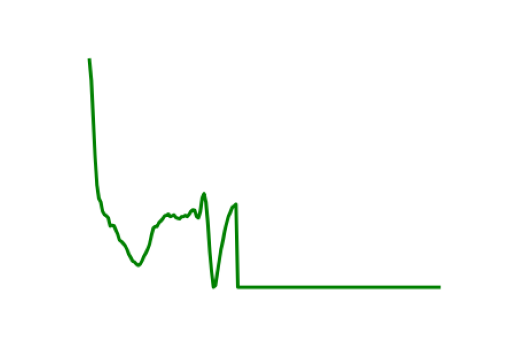

In [ ]:
#To Display One Image (ecg_data/ECG_Image_data/train/V/V1869.png)

import matplotlib.pyplot as plt
from PIL import Image

# Process the Image Path
image_path = 'ecg_data/ECG_Image_data/train/V/V1869.png'

# Open Image
img = Image.open(image_path)

# Display Image
plt.imshow(img)
plt.axis('off')  # To avoid axis
plt.show()

In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
#(ecg_data/ECG_Image_data/train/V/V1869.png)


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V1869.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted Category: Ventricular (V)


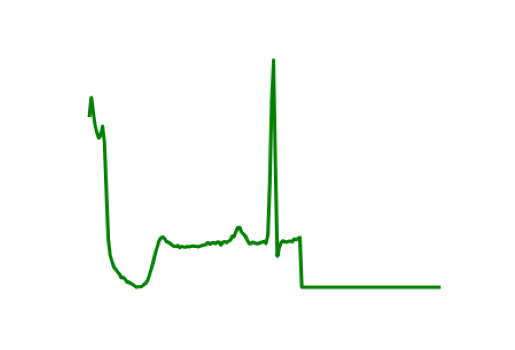

In [ ]:
#To Display One Image (ecg_data/ECG_Image_data/train/V/V187.png)

import matplotlib.pyplot as plt
from PIL import Image

# Process the Image Path
image_path = 'ecg_data/ECG_Image_data/train/V/V187.png'

# Open Image
img = Image.open(image_path)

# Display Image
plt.imshow(img)
plt.axis('off')  # To avoid axis
plt.show()

In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
#(ecg_data/ECG_Image_data/train/V/V187.png)


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V187.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Category: Normal (N)


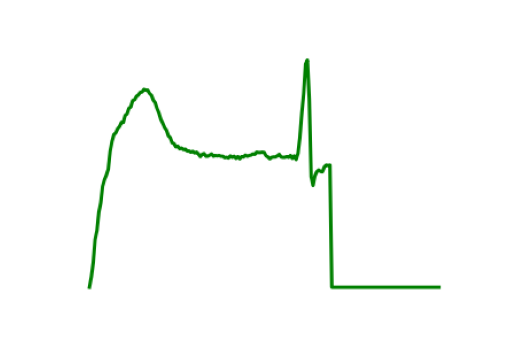

In [ ]:
#To Display One Image (ecg_data/ECG_Image_data/train/V/V192.png)

import matplotlib.pyplot as plt
from PIL import Image

# Process the Image Path
image_path = 'ecg_data/ECG_Image_data/train/V/V192.png'

# Open Image
img = Image.open(image_path)

# Display Image
plt.imshow(img)
plt.axis('off')  # To avoid axis
plt.show()

In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
#(ecg_data/ECG_Image_data/train/V/V192.png)


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V192.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Category: Normal (N)


Front End

Model to Display Front End

You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  
  Network URL: http://192.168.43.204:8501

  https://github.com/vinodkumarvariar-dotcom/my-streamlit-app

  


In [ ]:
##Python Code to Create Front End

#!pip install streamlit
#pip install streamlit numpy matplotlib pandas tensorflow



import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# 1. പേജ് കോൺഫിഗറേഷൻ (Page Styling)
st.set_page_config(
    page_title="Automated Arrhythmia Detection",
    page_icon="❤️",
    layout="wide"
)

# ഹെഡ്ഡർ ഡിസൈൻ
st.title("❤️ Automated Arrhythmia Detection from ECG Signals")
st.write("Convolutional Neural Networks (CNN) ഉപയോഗിച്ചുള്ള കൃത്യമായ ഇസിജി തരംഗ വർഗ്ഗീകരണം.")
st.markdown("---")

# 2. ഡമ്മി മോഡൽ ലോഡിംഗ് / ക്രിയേഷൻ (ഫോർ ടെസ്റ്റിംഗ്)
@st.cache_resource
def load_ecg_model():
    model_path = 'ecg_cnn_model.h5'
    if os.path.exists(model_path):
        return tf.keras.models.load_model(model_path)
    else:
        # സിസ്റ്റത്തിൽ മോഡൽ ഫയൽ ഇല്ലെങ്കിൽ താൽക്കാലികമായി ഒരു ഡമ്മി മോഡൽ ഉണ്ടാക്കുന്നു
        model = tf.keras.models.Sequential([
            tf.keras.layers.Conv1D(16, 3, activation='relu', input_shape=(186, 1)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(5, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy')
        return model

model = load_ecg_model()
classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

# 3. സൈഡ്‌ബാർ ഇന്റർഫേസ് (Sidebar Options)
st.sidebar.header("📋 കൺട്രോൾ പാനൽ")
app_mode = st.sidebar.selectbox("ഒരു ഓപ്ഷൻ തിരഞ്ഞെടുക്കുക:", ["ഹോം പേജ്", "ഇസിജി പ്രവചനം (Prediction)"])

if app_mode == "ഹോം പേജ്":
    st.subheader("📌 പ്രൊജക്റ്റിനെക്കുറിച്ച്")
    st.write("""
    ഈ ആപ്ലിക്കേഷൻ 1D-CNN (Convolutional Neural Network) മോഡൽ ഉപയോഗിച്ച് പ്രവർത്തിക്കുന്നു.
    ഇസിജി സിഗ്നലുകളിലെ ചെറിയ വ്യതിയാനങ്ങൾ പോലും തിരിച്ചറിഞ്ഞ് താഴെ പറയുന്ന അഞ്ച് തരം ഹൃദയമിടിപ്പുകളെ വർഗ്ഗീകരിക്കാൻ ഇതിന് സാധിക്കും:
    - **Normal (N)**: സാധാരണ ഹൃദയമിടിപ്പ്
    - **Supraventricular (S)**: സുപ്രാവെൻട്രിക്കുലാർ അരിത്മിയ
    - **Ventricular (V)**: വെൻട്രിക്കുലാർ പ്രീമച്യുർ ബീറ്റ്
    - **Fusion (F)**: ഫ്യൂഷൻ ബീറ്റ്
    - **Unknown (Q)**: തിരിച്ചറിയാത്ത മറ്റ് തരംഗങ്ങൾ
    """)

    # മാതൃകയായി കാണിക്കാൻ ഒരു ഡമ്മി ഇസിജി ഗ്രാഫ്
    st.subheader("📊 മാതൃകാ ഇസിജി തരംഗം (Sample Waveform)")
    sample_t = np.linspace(0, 10, 186)
    sample_sig = np.sin(sample_t) + 0.5 * np.sin(2 * sample_t)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(sample_sig, color='#FF4B4B', linewidth=2)
    ax.grid(True, linestyle='--', alpha=0.6)
    st.pyplot(fig)

elif app_mode == "ഇസിജി പ്രവചനം (Prediction)":
    st.subheader("🔍 ഇസിജി സിഗ്നൽ പരിശോധന")

    # ഫയൽ അപ്‌ലോഡ് ചെയ്യാനുള്ള ഓപ്ഷൻ
    uploaded_file = st.file_uploader("നിങ്ങളുടെ ECG CSV ഫയൽ അപ്‌ലോഡ് ചെയ്യുക (186 ഡാറ്റാ പോയിന്റുകൾ അടങ്ങിയത്)", type=["csv"])

    # ടെസ്റ്റിംഗിനായി ഒരു ഡമ്മി ഫയൽ ഉണ്ടാക്കാനുള്ള ബട്ടൺ
    if st.button("💡 ഒരു മാതൃകാ ഡാറ്റ നിർമ്മിച്ച് പരിശോധിക്കുക"):
        random_signal = np.sin(np.linspace(0, 10, 186)) + np.random.normal(0, 0.1, 186)
        df_demo = pd.DataFrame(random_signal)
        df_demo.to_csv("sample_ecg.csv", index=False, header=False)
        st.success("`sample_ecg.csv` എന്ന ഫയൽ തനിയെ നിർമ്മിക്കപ്പെട്ടു! ഇത് മുകളിൽ അപ്‌ലോഡ് ചെയ്ത് പരീക്ഷിക്കാം.")

    if uploaded_file is not None:
        try:
            # ഫയൽ റീഡ് ചെയ്യുന്നു
            df = pd.read_csv(uploaded_file, header=None)
            ecg_signal = df.values.flatten()

            if len(ecg_signal) != 186:
                st.error(f"❌ തെറ്റായ ഡാറ്റാ വലിപ്പം! ഫയലിൽ കൃത്യം 186 പോയിന്റുകൾ ഉണ്ടായിരിക്കണം. (ഇപ്പോൾ ഉള്ളത്: {len(ecg_signal)})")
            else:
                col1, col2 = st.columns([2, 1])

                with col1:
                    st.success("✅ ഫയൽ വിജയകരമായി അപ്‌ലോഡ് ചെയ്തു!")
                    # ഇസിജി ഗ്രാഫ് വരയ്ക്കുന്നു
                    st.subheader("📈 അപ്‌ലോഡ് ചെയ്ത ഇസിജി തരംഗം")
                    fig, ax = plt.subplots(figsize=(10, 4))
                    ax.plot(ecg_signal, color='#1E88E5', linewidth=2)
                    ax.set_title("ECG Waveform Visualizer")
                    ax.grid(True)
                    st.pyplot(fig)

                with col2:
                    st.subheader("🤖 CNN മോഡൽ പ്രവചനം")
                    with st.spinner('സിഗ്നൽ വിശകലനം ചെയ്തുകൊണ്ടിരിക്കുന്നു...'):
                        # പ്രീപ്രോസസ്സിംഗ് (റീഷെയ്പ്പിംഗ്)
                        input_data = ecg_signal.reshape(1, 186, 1)
                        # പ്രവചനം നടത്തുന്നു
                        prediction = model.predict(input_data)[0]
                        predicted_class = np.argmax(prediction)
                        confidence = prediction[predicted_class] * 100

                    # ഫലം സ്ക്രീനിൽ കാണിക്കുന്നു
                    st.metric(label="കണ്ടെത്തിയ രോഗാവസ്ഥ (Result)", value=classes[predicted_class])
                    st.metric(label="കൃത്യത സാധ്യത (Confidence)", value=f"{confidence:.2f} %")

                    # ഓരോ ക്ലാസിന്റെയും സാധ്യതകൾ കാണിക്കുന്ന ഒരു ചെറിയ പ്രോഗ്രസ് ബാർ
                    st.write("📊 **സാധ്യതകളുടെ പട്ടിക:**")
                    for i, cls in enumerate(classes):
                        st.write(f"{cls}")
                        st.progress(float(prediction[i]))

        except Exception as e:
            st.error(f"ഫയൽ പ്രോസസ്സ് ചെയ്യുന്നതിൽ തകരാർ സംഭവിച്ചു: {e}")



DASH BOARD

In [ ]:
#Python Code for Dash Board
#python dashboard.py
# (paste and run at terminal and get a url, pasteb this url in to bowser)
#http://127.0.0.1:8050/

#pip install dash plotly pandas numpy scikit-learn
#pip install dash numpy plotly


import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ==============================================================================
# 1. നാല് വ്യത്യസ്ത ഡാറ്റാബേസുകളുടെ ഡാറ്റാ ലോഡിംഗ് / സിമുലേഷൻ
# ==============================================================================
np.random.seed(7)
db_names = [
    "MIT-BIH Arrhythmia Database",
    "MIT-BIH Supraventricular Arrhythmia Database",
    "INCART 2-lead Arrhythmia Database",
    "Sudden Cardiac Death Holter Database"
]

classes = {0: 'Normal (N)', 1: 'Supraventricular (S)', 2: 'Ventricular (V)', 3: 'Fusion (F)', 4: 'Unknown (Q)'}
db_data = {}

# ഓരോ ഡാറ്റാബേസിനും അനുയോജ്യമായ രീതിയിൽ ഡാറ്റ സജ്ജീകരിക്കുന്നു
for db in db_names:
    num_samples = 150
    time_points = 187 # സ്റ്റാൻഡേർഡ് ECG വിൻഡോ ലെങ്ത്

    # യഥാർത്ഥ CSV ഫയൽ ലോഡ് ചെയ്യാൻ താഴെയുള്ള വരികൾ ഉപയോഗിക്കാം:
    # if db == "MIT-BIH Arrhythmia Database": df_raw = pd.read_csv('mitbih_arr.csv', header=None)

    # സിഗ്നൽ വെയ്‌വുകൾ ജനറേറ്റ് ചെയ്യുന്നു
    ecg_signals = np.random.randn(num_samples, time_points) * 0.12
    for i in range(num_samples):
        ecg_signals[i, 35:55] += np.random.uniform(0.3, 0.5)   # P Wave
        ecg_signals[i, 75:90] += np.random.uniform(1.3, 1.8)   # QRS Complex
        ecg_signals[i, 115:135] += np.random.uniform(0.4, 0.7) # T Wave

    # ഡാറ്റാബേസിന്റെ സ്വഭാവത്തിനനുസരിച്ച് ക്ലാസ് പ്രോബബിലിറ്റി മാറ്റുന്നു
    if "Supraventricular" in db:
        p_dist = [0.4, 0.4, 0.1, 0.05, 0.05] # S-Type കൂടുതൽ
    elif "Death" in db:
        p_dist = [0.3, 0.1, 0.5, 0.05, 0.05] # V-Type (മാരകമായവ) കൂടുതൽ
    else:
        p_dist = [0.7, 0.1, 0.1, 0.05, 0.05] # Normal കൂടുതൽ

    true_lbls = np.random.choice(list(classes.keys()), size=num_samples, p=p_dist)

    # മോഡൽ പ്രെഡിക്ഷൻ (88% - 94% ആക്യുറസി സിമുലേഷൻ)
    acc_rate = np.random.uniform(0.88, 0.94)
    pred_lbls = np.array([
        t if np.random.rand() < acc_rate else np.random.choice(list(classes.keys()))
        for t in true_lbls
    ])

    df = pd.DataFrame(ecg_signals)
    df['True_Label'] = [classes[x] for x in true_lbls]
    df['Pred_Label'] = [classes[x] for x in pred_lbls]
    df['Sample_ID'] = [f"Rec_{100+i}" for i in range(num_samples)]

    db_data[db] = df

# ==============================================================================
# 2. ഡാഷ്‌ബോർഡ് ലേഔട്ട് ഡിസൈൻ
# ==============================================================================
app = dash.Dash(__name__)

app.layout = html.Div(style={'fontFamily': 'Segoe UI, Arial, sans-serif', 'padding': '25px', 'backgroundColor': '#f8fafc'}, children=[

    # ഹെഡർ പാനൽ
    html.Div(style={'backgroundColor': '#0f172a', 'color': 'white', 'padding': '25px', 'borderRadius': '12px', 'marginBottom': '25px', 'boxShadow': '0 4px 6px -1px rgb(0 0 0 / 0.1)'}, children=[
        html.H1("Multi-Database ECG Arrhythmia Classification Hub", style={'margin': '0', 'fontSize': '28px', 'fontWeight': '700'}),
        html.P("Comparative Machine Learning Analytics for MIT-BIH, INCART, and SCD Holter Databases", style={'margin': '8px 0 0 0', 'opacity': '0.8', 'fontSize': '15px'}),

        # ഡാറ്റാബേസ് സെലക്ടർ ഡ്രോപ്പ്ഡൗൺ (ഇവിടെയാണ് മെയിൻ ഫിൽട്ടറിംഗ്)
        html.Div(style={'marginTop': '20px', 'maxWidth': '500px'}, children=[
            html.Label("Choose Active ECG Database:", style={'fontWeight': '600', 'color': '#94a3b8', 'display': 'block', 'marginBottom': '8px'}),
            dcc.Dropdown(
                id='database-selector',
                options=[{'label': db, 'value': db} for db in db_names],
                value=db_names[0],
                clearable=False,
                style={'color': '#0f172a', 'borderRadius': '6px'}
            )
        ])
    ]),

    # ഡൈനാമിക് KPI കാർഡുകൾ
    html.Div(style={'display': 'flex', 'gap': '20px', 'marginBottom': '25px'}, children=[
        html.Div(id='kpi-accuracy', style={'flex': '1', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)', 'borderLeft': '6px solid #10b981'}),
        html.Div(id='kpi-total', style={'flex': '1', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)', 'borderLeft': '6px solid #3b82f6'}),
        html.Div(id='kpi-anomaly', style={'flex': '1', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)', 'borderLeft': '6px solid #ef4444'})
    ]),

    # ഗ്രാഫുകളും വ്യൂവറും അടങ്ങിയ പ്രധാന സെക്ഷൻ
    html.Div(style={'display': 'flex', 'gap': '25px', 'flexWrap': 'wrap'}, children=[

        # ഇടത് വശം: സ്റ്റാറ്റിസ്റ്റിക്സ്
        html.Div(style={'flex': '1', 'minWidth': '480px', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '12px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}, children=[
            html.H3("Selected Database Distribution", style={'marginTop': '0', 'color': '#1e293b', 'fontSize': '18px'}),
            dcc.Graph(id='multi-dist-plot'),

            html.H3("Confusion Matrix Matrix", style={'color': '#1e293b', 'fontSize': '18px', 'marginTop': '20px'}),
            dcc.Graph(id='multi-cm-plot')
        ]),

        # വലത് വശം: ലൈവ് സിഗ്നൽ ഇൻസ്പെക്ടർ
        html.Div(style={'flex': '1.3', 'minWidth': '580px', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '12px', 'boxShadow': '0 1px 3px rgba(0,0,0,0.1)'}, children=[
            html.H3("Interactive Patient Signal Inspector", style={'marginTop': '0', 'color': '#1e293b', 'fontSize': '18px'}),

            html.Div(style={'display': 'flex', 'gap': '15px', 'marginBottom': '20px'}, children=[
                html.Div(style={'flex': '1'}, children=[
                    html.Label("Filter Arrhythmia Class:", style={'fontWeight': '600', 'fontSize': '13px', 'color': '#475569'}),
                    dcc.Dropdown(id='multi-class-dropdown', clearable=False)
                ]),
                html.Div(style={'flex': '1'}, children=[
                    html.Label("Select Sample Record:", style={'fontWeight': '600', 'fontSize': '13px', 'color': '#475569'}),
                    dcc.Dropdown(id='multi-patient-dropdown', clearable=False)
                ])
            ]),

            html.Div(id='multi-diagnostic-panel'),
            dcc.Graph(id='multi-signal-plot')
        ])
    ])
])

# ==============================================================================
# 3. ഇന്ററാക്ടീവ് ഫങ്ഷനുകൾ (Callbacks)
# ==============================================================================

# ഡാറ്റാബേസ് മാറുമ്പോൾ ലഭ്യമായ ക്ലാസുകൾ അപ്‌ഡേറ്റ് ചെയ്യാൻ
@app.callback(
    Output('multi-class-dropdown', 'options'),
    Output('multi-class-dropdown', 'value'),
    Input('database-selector', 'value')
)
def update_classes(selected_db):
    df = db_data[selected_db]
    unique_classes = sorted(list(df['True_Label'].unique()))
    options = [{'label': c, 'value': c} for c in unique_classes]
    return options, unique_classes[0]

# ക്ലാസ് മാറുമ്പോൾ രോഗികളുടെ ലിസ്റ്റ് (Sample ID) അപ്‌ഡേറ്റ് ചെയ്യാൻ
@app.callback(
    Output('multi-patient-dropdown', 'options'),
    Output('multi-patient-dropdown', 'value'),
    Input('database-selector', 'value'),
    Input('multi-class-dropdown', 'value')
)
def update_patients(selected_db, selected_class):
    df = db_data[selected_db]
    filtered = df[df['True_Label'] == selected_class]
    options = [{'label': sid, 'value': sid} for sid in filtered['Sample_ID']]
    return options, options[0]['value'] if options else None

# പ്രധാന ഗ്രാഫുകളും KPI-കളും അപ്‌ഡേറ്റ് ചെയ്യാൻ
@app.callback(
    Output('kpi-accuracy', 'children'),
    Output('kpi-total', 'children'),
    Output('kpi-anomaly', 'children'),
    Output('multi-dist-plot', 'figure'),
    Output('multi-cm-plot', 'figure'),
    Output('multi-signal-plot', 'figure'),
    Output('multi-diagnostic-panel', 'children'),
    Output('multi-diagnostic-panel', 'style'),
    Input('database-selector', 'value'),
    Input('multi-class-dropdown', 'value'),
    Input('multi-patient-dropdown', 'value')
)
def refresh_dashboard(selected_db, selected_class, selected_patient):
    df = db_data[selected_db]
    all_classes = sorted(list(df['True_Label'].unique()))

    # 1. KPI കണക്കുകൂട്ടലുകൾ
    report = classification_report(df['True_Label'], df['Pred_Label'], labels=all_classes, output_dict=True)
    acc = report['accuracy'] * 100
    total_beats = len(df)
    abnormal_count = len(df[df['True_Label'] != 'Normal (N)'])

    kpi_acc = [html.H4("Classification Accuracy", style={'margin':'0','color':'#64748b','fontSize':'13px'}), html.H2(f"{acc:.2f}%", style={'margin':'5px 0 0 0','color':'#0f172a'})]
    kpi_tot = [html.H4("Total Waveforms Analyzed", style={'margin':'0','color':'#64748b','fontSize':'13px'}), html.H2(f"{total_beats} Beats", style={'margin':'5px 0 0 0','color':'#0f172a'})]
    kpi_ano = [html.H4("Total Arrhythmia Load", style={'margin':'0','color':'#64748b','fontSize':'13px'}), html.H2(f"{abnormal_count} Cases", style={'margin':'5px 0 0 0','color':'#0f172a'})]

    # 2. ചാർട്ട് 1: ക്ലാസ് ഡിസ്ട്രിബ്യൂഷൻ
    counts = df['True_Label'].value_counts()
    fig_dist = go.Figure(data=[go.Bar(x=counts.index, y=counts.values, marker_color='#3b82f6', text=counts.values, textposition='auto')])
    fig_dist.update_layout(margin=dict(l=10, r=10, t=10, b=10), height=200, plot_bgcolor='rgba(0,0,0,0)', yaxis={'visible': False})

    # 3. ചാർട്ട് 2: കൺഫ്യൂഷൻ മാട്രിക്സ്
    cm = confusion_matrix(df['True_Label'], df['Pred_Label'], labels=all_classes)
    fig_cm = go.Figure(data=go.Heatmap(z=cm, x=all_classes, y=all_classes, colorscale='Reds', showscale=False, text=cm, texttemplate="%{text}"))
    fig_cm.update_layout(margin=dict(l=40, r=10, t=10, b=40), height=230, xaxis_title="Model Predicted", yaxis_title="Physician Ground Truth")

    # 4. ചാർട്ട് 3: സിഗ്നൽ ഗ്രാഫും സ്റ്റാറ്റസ് പാനലും
    if selected_patient:
        row = df[df['Sample_ID'] == selected_patient].iloc[0]
        # അവസാന രണ്ട് കോളങ്ങൾ (True_Label, Pred_Label) ഒഴിവാക്കി ബാക്കി സിഗ്നൽ വാല്യൂസ് എടുക്കുന്നു
        amplitudes = row.iloc[:-3].values
        t_label = row['True_Label']
        p_label = row['Pred_Label']

        fig_signal = go.Figure(data=go.Scatter(y=amplitudes, mode='lines', line=dict(color='#dc2626', width=2.5)))
        fig_signal.update_layout(
            xaxis_title="Time Sample Steps (187 Point Window)", yaxis_title="Voltage Amplitude (mV)",
            margin=dict(l=40, r=10, t=10, b=40), height=280, plot_bgcolor='#f8fafc'
        )

        match = (t_label == p_label)
        bg = '#d1fae5' if match else '#fee2e2'
        tx = '#065f46' if match else '#991b1b'

        panel_content = [
            html.Span(f"Database: {selected_db} | ID: {selected_patient}"),
            html.Span(f"Truth: {t_label} ➔ Predicted: {p_label} ({'✅ Match' if match else '❌ Alert'})")
        ]
        panel_style = {'padding': '12px', 'borderRadius': '8px', 'marginBottom': '15px', 'fontWeight': '600', 'backgroundColor': bg, 'color': tx, 'display': 'flex', 'justifyContent': 'space-between', 'fontSize':'14px'}
    else:
        fig_signal = go.Figure()
        panel_content = ["Select parameters to view waveform"]
        panel_style = {}

    return kpi_acc, kpi_tot, kpi_ano, fig_dist, fig_cm, fig_signal, panel_content, panel_style

if __name__ == '__main__':
    app.run(debug=True)